In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

from plotting import plot_model_comparison

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
dataset_name = "crc" # Options: merfish, crc

In [20]:
corr_dir = f"/data2/a330d/datasets/{dataset_name}/correlations"
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[len("crc_"):-len(".json")] if dataset_name == "crc" else name[:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": f"crc_{sid}" if dataset_name == "crc" else sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),            
            "rmse": data.get("rmse"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc_120,baseline-cf,Endothelial_CRC,50,0.548619,0.497170,0.10,1.000000,0.10,0.547060,13.249699,15.278936,5856.333946
1,crc_120,baseline-cf,Epithelial_CRC,50,0.442017,0.330887,0.26,0.769231,0.20,0.895650,9.924456,8.871777,652016.069078
2,crc_120,baseline-cf,Fibroblast_CRC,50,0.378247,0.385970,0.16,1.000000,0.16,0.605086,8.445271,10.781323,180004.851410
3,crc_120,baseline-cf,Myeloid_CRC,50,0.510492,0.456200,0.14,1.000000,0.14,0.502754,14.798410,16.269466,36416.168085
4,crc_120,baseline-cf,T_cell_CRC,50,0.836351,0.712031,0.12,1.000000,0.12,0.797638,16.806622,18.496396,22608.232002


In [21]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc_120,baseline,Endothelial_CRC,50,0.548619,0.497170,0.10,1.000000,0.10,0.547060,13.249699,15.278936,5856.333946
1,crc_120,baseline,Epithelial_CRC,50,0.442017,0.330887,0.26,0.769231,0.20,0.895650,9.924456,8.871777,652016.069078
2,crc_120,baseline,Fibroblast_CRC,50,0.378247,0.385970,0.16,1.000000,0.16,0.605086,8.445271,10.781323,180004.851410
3,crc_120,baseline,Myeloid_CRC,50,0.510492,0.456200,0.14,1.000000,0.14,0.502754,14.798410,16.269466,36416.168085
4,crc_120,baseline,T_cell_CRC,50,0.836351,0.712031,0.12,1.000000,0.12,0.797638,16.806622,18.496396,22608.232002


In [22]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [23]:
def unify_formatting(df_parent, df_child):
    df_child["holdout_celltype"] = df_child["holdout_celltype"] + "_" + df_child["target_domain"]
    df_child["sid"] = df_child["sid"].astype(str)

    common_cols = df_parent.columns
    df_child_trimmed = df_child[common_cols.intersection(df_child.columns)]
    combined = pd.concat([df_parent, df_child_trimmed], axis=0, ignore_index=True)

    return combined

In [24]:
# Load mintflow results
mintflow_base_path = f"/data/a330d/projects/cellina-reproducibility-worktrees/major-loo/results/mintflow_{dataset_name}"
mintflow_df = pd.DataFrame()

# Loop over mintflow_base_path and read each file, concatenate into mintflow_df
for file in glob.glob(f"{mintflow_base_path}/mintflow_*.csv"):
    temp_df = pd.read_csv(file)
    mintflow_df = pd.concat([mintflow_df, temp_df], ignore_index=True)
    mintflow_df = mintflow_df[mintflow_df["n_deg"] == n_deg]
mintflow_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc,crc_221,REF,CRC,50,mintflow,Endothelial,0.469004,0.509283,0.86,1.0,0.86,0.619056,10.831748,12.051200,26873.515624
1,crc,crc_221,REF,CRC,50,mintflow,Epithelial,0.671164,0.850785,0.20,1.0,0.20,0.731140,12.152723,14.492969,306056.287536
2,crc,crc_221,REF,CRC,50,mintflow,Fibroblast,0.437215,0.630816,0.16,1.0,0.16,0.443244,13.944429,17.650007,120079.537218
3,crc,crc_221,REF,CRC,50,mintflow,Myeloid,0.537575,0.537871,0.72,1.0,0.72,0.341953,11.027860,12.498062,36025.760864
4,crc,crc_221,REF,CRC,50,mintflow,T_cell,0.750588,0.876193,0.42,1.0,0.42,0.793514,14.736452,17.565509,39673.762863


In [25]:
combined_df = unify_formatting(df, mintflow_df)

In [26]:
spprop_csv_path = f'../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}.csv'
spprop_df = pd.read_csv(spprop_csv_path)
spprop_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse,top_n_perturb
0,crc,crc_232,REF,CRC,50,spatialprop,Endothelial,0.362209,0.256007,0.02,1.0,0.02,0.767721,9.176776,13.297079,10328.555,2000
1,crc,crc_232,REF,CRC,50,spatialprop,Epithelial,-0.220744,-0.295531,0.00,0.0,0.00,0.749886,8.492295,12.792121,90294.810,2000
2,crc,crc_232,REF,CRC,50,spatialprop,Fibroblast,0.098295,0.097671,0.02,0.0,0.00,0.745542,7.984793,12.801423,35687.676,2000
3,crc,crc_232,REF,CRC,50,spatialprop,Myeloid,0.421273,0.483267,0.02,1.0,0.02,0.999801,9.047005,13.929147,10705.336,2000
4,crc,crc_232,REF,CRC,50,spatialprop,T_cell,0.276927,0.553492,0.04,0.5,0.02,0.612603,12.223564,13.494719,5719.572,2000


In [27]:
combined_df = unify_formatting(combined_df, spprop_df)

In [31]:
# Add node-perturbation results
cellina_pert_df = pd.read_csv(f"../results/loo_cellina_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
spprop_pert_df = pd.read_csv(f"../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
spprop_pert_df['model_name'] += "-pert"

In [34]:
combined_df = unify_formatting(combined_df, cellina_pert_df)
combined_df = unify_formatting(combined_df, spprop_pert_df)

In [35]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "spatialprop",
    "cpa",
    "scgen",
    "cellina-ablated",
    "cellina-graph",
    "cellina",
    "spatialprop-pert",
    "cellina-pert"
]

default_palette = 'colorblind'
palette = default_palette

In [36]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]
palette_dict["cellina-pert"]         = cellina_reds[3]

# non-spatial green
palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
palette_dict["spatialprop"]   = sns.color_palette("Greens", 4)[0]
palette_dict["spatialprop-pert"]   = sns.color_palette("Greens", 4)[0]

palette = palette_dict

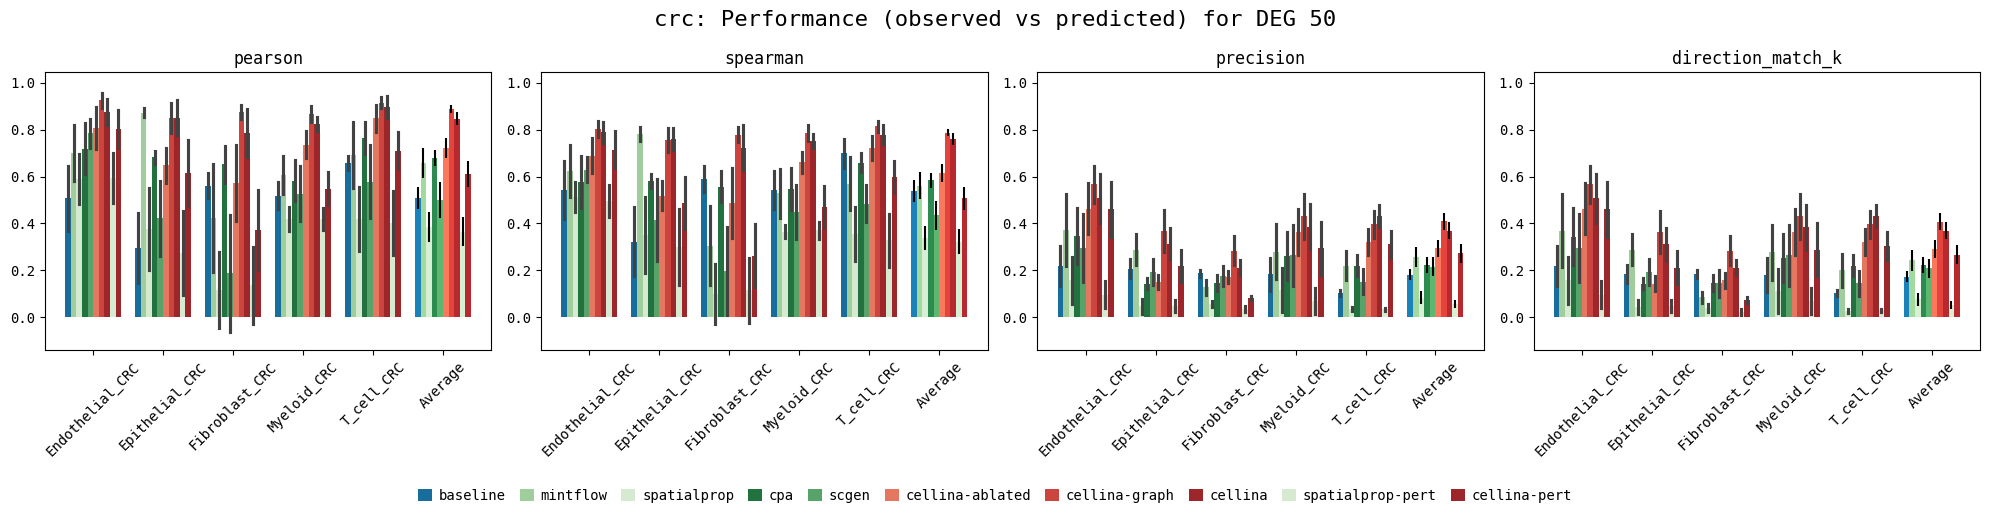

In [37]:
metrics = ["pearson", "spearman", "precision", "direction_match_k"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

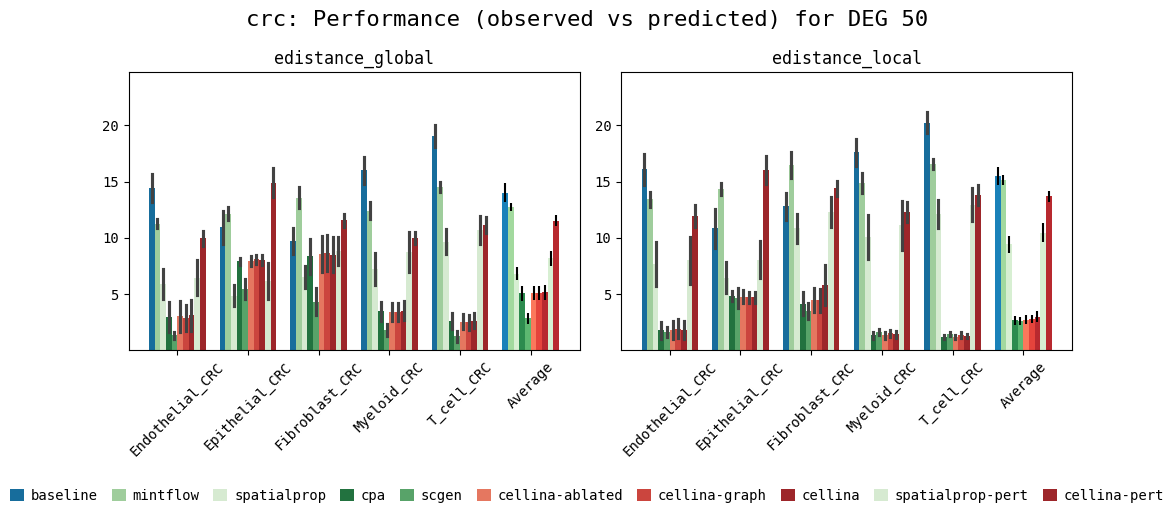

In [38]:
metrics = ["edistance_global", "edistance_local"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

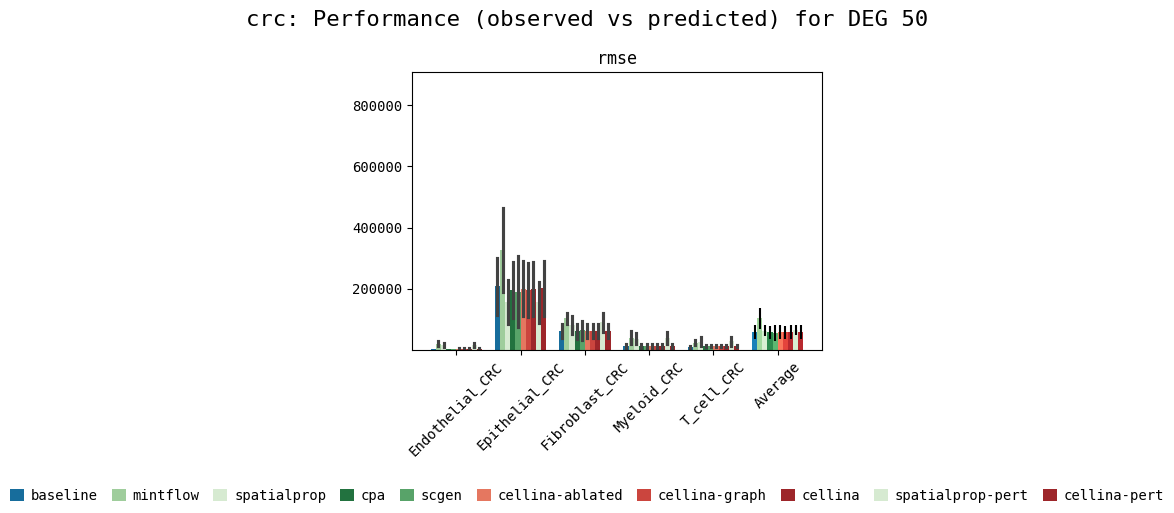

In [39]:
metrics = ["rmse"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

In [40]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)

## Add average rank column

In [28]:
metrics = [
    "pearson",
    #"spearman",
    "precision",
    #"direction_match",
    #"rmse",
    "edistance_local",
]

direction = {
    "pearson": "higher",
    #"spearman": "higher",
    "precision": "higher",
    #"direction_match": "higher",
    #"rmse": "lower",
    "edistance_local": "lower",
}

In [ ]:
df_ranked = combined_df.copy()

# compute ranks only temporarily
rank_cols = []
group_cols = ["sid", "holdout_celltype"]

for m in metrics:
    ascending = direction[m] == "lower"

    rank_col = f"{m}_rank"
    df_ranked[rank_col] = (
        df_ranked.groupby(group_cols)[m]
        .rank(ascending=ascending, method="average")
    )
    rank_cols.append(rank_col)

# final aggregate rank
df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)

# drop intermediate rank columns
df_ranked = df_ranked.drop(columns=rank_cols)

In [ ]:
df_ranked

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse,avg_rank
0,crc_120,baseline,Endothelial_CRC,50,0.548619,0.497170,0.10,1.000000,0.10,0.547060,13.249699,15.278936,5856.333946,6.500000
1,crc_120,baseline,Epithelial_CRC,50,0.442017,0.330887,0.26,0.769231,0.20,0.895650,9.924456,8.871777,652016.069078,5.666667
2,crc_120,baseline,Fibroblast_CRC,50,0.378247,0.385970,0.16,1.000000,0.16,0.605086,8.445271,10.781323,180004.851410,5.000000
3,crc_120,baseline,Myeloid_CRC,50,0.510492,0.456200,0.14,1.000000,0.14,0.502754,14.798410,16.269466,36416.168085,5.666667
4,crc_120,baseline,T_cell_CRC,50,0.836351,0.712031,0.12,1.000000,0.12,0.797638,16.806622,18.496396,22608.232002,5.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,crc_120,spatialprop,Endothelial_CRC,50,0.563505,0.499551,0.04,1.000000,0.04,0.812261,6.878066,9.875358,43287.758000,6.333333
226,crc_120,spatialprop,Epithelial_CRC,50,0.663481,0.607788,0.04,1.000000,0.04,0.779179,6.894642,7.006116,501439.750000,6.333333
227,crc_120,spatialprop,Fibroblast_CRC,50,0.049412,-0.074937,0.06,0.333333,0.02,0.693359,5.286521,8.863244,229567.550000,5.833333
228,crc_120,spatialprop,Myeloid_CRC,50,0.397839,0.450173,0.04,1.000000,0.04,0.744805,10.499007,13.860851,120845.555000,6.000000


In [36]:
df_ranked.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}_ranked.csv", index=False)